# Infer Functional Cell Cell Communication

This notebook walks through infering cell-cell communication events that drive specific cell states

![title](../../assets/ccc.png)

SpaceTravLR differs from most current computational approaches to study intercellular communication. Current approaches study intercellular communication from (single-cell) expression data by linking ligands expressed by sender cells to their corresponding receptors expressed by receiver cells. However, 

A functional understanding of a cellular communication process requires knowing how these inferred ligand-receptor interactions result in changes in the expression of downstream target genes within the receiver cells. 

Contrary to existing approaches, SpaceTravLR models the gene regulatory effects of ligands to predict which ligands influence the expression in another cell, which target genes are affected by each ligand and which signaling mediators may be involved. By generating these novel types of hypotheses, SpaceTravLR can drive an improved functional understanding of a cell-cell communication process of interest. 

In [32]:
import pandas as pd
import scanpy as sc
import sys 
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append('/Users/koush/Projects/SpaceOracle/src')

In [2]:
from SpaceTravLR.beta import Betabase

In [3]:
adata = sc.read_h5ad('/Volumes/SSD/training_data/snrna_human_melanoma.h5ad')
adata

AnnData object with n_obs × n_vars = 4804 × 3396
    obs: 'X', 'Y', 'cell_type', 'author_cell_type', 'cell_type_int'
    uns: 'author_cell_type_colors', 'cell_thresholds', 'neighbors', 'pca', 'received_ligands', 'received_ligands_tfl', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_unscaled'
    varm: 'PCs'
    layers: 'imputed_count', 'normalized_count'
    obsp: 'connectivities', 'distances'

In [4]:
bdb = Betabase(
    adata=adata, 
    folder='/Volumes/SSD/lasso_runs/human_melanoma_v2', 
    auto_load=False
)


In [7]:
interactions = bdb.collect_interactions(cell_type='CD8+ T')

In [9]:
activation_genes = [
    'CD8A', 'GZMK', 'IFNG', 'PRF1', 
    'CD69', 'TBX21', 'GZMA', 'GZMB'
]

interactions.sort_values(
    by='beta', 
    ascending=False, 
    key=abs).query('gene in @activation_genes')

,interaction,gene,beta,interaction_type
CD8+ T,,,,
162744,beta_IL7$IL7R,GZMA,-1.440270e+01,ligand-receptor
34403,beta_THRB,GZMK,6.914885e+00,tf
287109,beta_ANGPT2$ITGB1,GZMA,5.198300e+00,ligand-receptor
162747,beta_IL7$IL7R,GZMK,-4.398692e+00,ligand-receptor
165047,beta_IL7$IL2RG,GZMA,3.815622e+00,ligand-receptor
...,...,...,...,...
548512,beta_COL6A2$ITGA10,GZMA,5.215077e-09,ligand-receptor
37178,beta_IFNG#GLIS3,TBX21,6.802419e-10,ligand-tf
819723,beta_SELL$MADCAM1,GZMK,-1.680157e-10,ligand-receptor


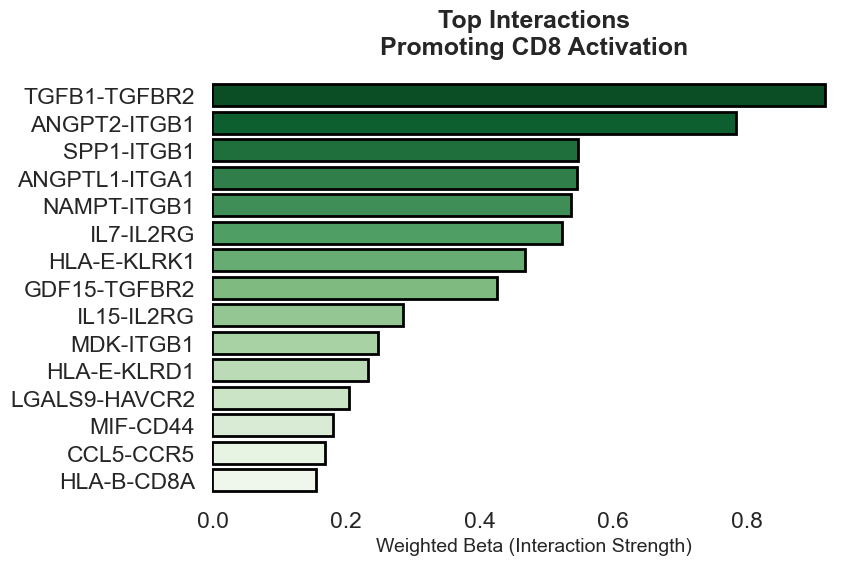

In [46]:
df = interactions.sort_values(
    by='beta', 
    ascending=False, 
    key=abs).query(
        'gene in @activation_genes and interaction_type == "ligand-receptor"')

cd8_means = adata.to_df(layer='imputed_count')[adata.obs['cell_type'] == "CD8+ T"].mean()
genes = df.interaction.str.split("$").str.get(1)
receptor_expr = genes.map(cd8_means)

df['weighted_beta'] = df['beta'] * receptor_expr

df_cd8 = df.copy()
df_cd8.interaction = df_cd8.interaction.str.replace('beta_', '')
df_cd8.interaction = df_cd8.interaction.str.replace('$', '-')

top_interactions = (
    df_cd8[['interaction', 'weighted_beta']].groupby(
        'interaction').mean().sort_values(by='weighted_beta', ascending=False)
      .head(15)
)

sns.set_theme(style="white", context="talk")
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=top_interactions,
    x="weighted_beta",
    y="interaction",
    hue="interaction",      
    palette="Greens_r",
    linewidth=2,
    edgecolor='black',         
    legend=False
)

ax.set_title("Top Interactions\nPromoting CD8 Activation", fontweight='bold', pad=20)
ax.set_xlabel("Weighted Beta (Interaction Strength)", fontsize=14)
ax.set_ylabel("")

sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()